In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv('/content/pakwheels.csv')

In [3]:
data.head(10)

,Unnamed: 0,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,PKR 16.5 lacs,"100,000 km",Petrol,Automatic,Lahore,Grey,Imported Cars,1800 cc,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,PKR 7 lacs,"100,000 km",Petrol,Manual,Faisalabad,Grey,Imported Cars,800 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,PKR 7.6 lacs,999 km,Petrol,Manual,Lahore,Black,Imported Cars,1500 cc,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,PKR 70 lacs,"94,000 km",Petrol,Automatic,Lahore,Black,Imported Cars,2700 cc,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,PKR 8 lacs,"86,000 km",Petrol,Manual,Multan,Grey,Imported Cars,796 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...
5,5,https://www.pakwheels.com/used-cars/toyota-cor...,Toyota Corolla Altis SR Cruisetronic 1.6 2012,"Gulberg, Peshawar KPK",2012.0,PKR 25.5 lacs,"85,000 km",Petrol,Automatic,Lahore,Silver,Imported Cars,1600 cc,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Toyota corolla 1.6sr edition1 piece touch2012 ...
6,6,https://www.pakwheels.com/used-cars/suzuki-mr-...,Suzuki MR Wagon WIT LIMITED 2011,"Rafi Qamar Road, Bahawalpur Punjab",2011.0,PKR 13 lacs,"97,000 km",Petrol,Automatic,Lahore,Silver,Imported,660 cc,Mini Van,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Alloy Rims. Original return file is available ...
7,7,https://www.pakwheels.com/used-cars/honda-br-v...,Honda BR-V i-VTEC S 2018,"Marala Road, Sialkot Punjab",2018.0,PKR 36 lacs,"56,000 km",Petrol,Automatic,Islamabad,Silver,Imported Cars,1500 cc,MPV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Lightweight ally rims . Fully maintained throu...
8,8,https://www.pakwheels.com/used-cars/toyota-cor...,Toyota Corolla Altis X Automatic 1.6 Special E...,Karachi Sindh,2018.0,PKR 36.6 lacs,"28,000 km",Petrol,Automatic,Karachi,Black,Imported Cars,1600 cc,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Just like a Zero Me...
9,9,https://www.pakwheels.com/used-cars/toyota-rai...,Toyota Raize 2020,Islamabad Islamabad,2020.0,PKR 51.75 lacs,"14,500 km",Petrol,Automatic,Un-Registered,White,Imported,1000 cc,NaN,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. All original docume...


In [4]:
data.dtypes

,0
Unnamed: 0,int64
ad_url,object
title,object
location,object
model_year,float64
price,object
mileage,object
engine_type,object
transmission,object
registered_in,object


In [5]:
data.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
data['title'] = data['title'].apply(lambda x: ' '.join(x.split()[:-1]))
title_unique = data['title'].nunique()
print(title_unique)
print(data['title'].unique()[:title_unique].tolist())




2146
['Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC', 'Suzuki Mehran VX Euro II', 'Honda Civic EX', 'Toyota Fortuner 2.7 VVTi', 'Toyota Corolla Altis SR Cruisetronic 1.6', 'Suzuki MR Wagon WIT LIMITED', 'Honda BR-V i-VTEC S', 'Toyota Corolla Altis X Automatic 1.6 Special Edition', 'Toyota Raize', 'Toyota Vitz B 1.0', 'Honda City 1.3 i-VTEC', 'Toyota Corolla Altis Grande CVT-i 1.8', 'Alfa Romeo Other', 'Toyota Hilux Revo V Automatic 2.8', 'Toyota Corolla 2.0D Special Edition', 'Changan Karvaan Plus', 'KIA Picanto', 'Mitsubishi Pajero GLX 3.2D', 'Toyota Passo X', 'Mitsubishi Lancer', 'Honda Accord VTi 2.4', 'Honda City 1.2L M/T', 'Suzuki Baleno JXR', 'Ford F 150 Raptor 3.5L Eco Boost', 'Honda Civic Oriel 1.8 i-VTEC CVT', 'Lexus LX Series LX570', 'Toyota Tacoma TRD Sport', 'Toyota Aqua G', 'Toyota Corolla GL Saloon', 'Toyota Vitz F 1.3', 'Toyota Corolla Altis 1.8', 'KIA Sportage FWD', 'Toyota Premio X EX Package 1.8', 'Honda Civic Oriel', 'Honda Insight HDD Navi Special Edition', 'Toyota Co

In [7]:
data['model_year'] = data['model_year'].astype('Int64')

In [8]:
data = data[data['price'] != 'Call for price']
def convert_price(price):

  price = str(price).replace('PKR', '').replace(',', '').strip()

  if 'lacs' in price:
    return float(price.replace('lacs', '')) * 100000
  elif 'crore' in price:
    return float(price.replace('crore', '')) * 10000000

  return float(price)

data['price'] = data['price'].apply(convert_price)


In [9]:
data['engine_capacity'] = data['engine_capacity'].str.replace('cc','').str.replace('kWh','').str.strip().astype('float')

In [10]:
data['mileage'] = data['mileage'].str.replace('km','').str.replace(',','').str.strip().astype('float')

In [11]:
data['assembly'] = data['assembly'].str.replace('Cars','').str.strip()
print(data['assembly'].unique())

['Imported']


In [12]:
data = data.replace('Nan', np.nan).dropna()

In [13]:
data['brand'] = data['title'].str.split(' ').str[0].str.strip().str.title()
print(data['brand'].unique())

['Honda' 'Suzuki' 'Toyota' 'Mitsubishi' 'Ford' 'Lexus' 'Kia' 'Daihatsu'
 'Faw' 'Mercedes' 'Changan' 'Mg' 'Hyundai' 'Proton' 'Nissan' 'Dfsk' 'Bmw'
 'Prince' 'Mini' 'Mazda' 'Jac' 'Audi' 'Baic' 'Daewoo' 'Chery' 'Haval'
 'Isuzu' 'Chevrolet' 'Peugeot' 'Porsche' 'Fiat' 'Jeep' 'Land' 'Range'
 'United' 'Subaru' 'Volkswagen' 'Ssangyong' 'Jmc' 'Gmc' 'Master' 'Hino'
 'Adam' 'Daehan' 'Jw' 'Jaguar' 'Sogo' 'Chrysler']


In [14]:
data['name'] = data['title'].str.split(' ').str[1].str.strip().str.title()
print(data['name'].unique())

['Civic' 'Mehran' 'Fortuner' 'Corolla' 'Mr' 'Br-V' 'Vitz' 'City' 'Hilux'
 'Pajero' 'Passo' 'Accord' 'Baleno' 'F' 'Lx' 'Tacoma' 'Aqua' 'Sportage'
 'Premio' 'Cultus' 'Wagon' 'Alto' 'Yaris' 'Tanto' 'Hiace' 'Prado' 'V2'
 'Probox' 'Fit' 'N' 'Swift' 'Every' 'Benz' 'X-Pv' 'Alsvin' 'Apv' 'Liana'
 'Hs' 'Spectra' 'Elantra' 'X70' 'Sorento' 'Ravi' 'Mira' 'Tucson' 'Saga'
 'Vezel' 'C-Hr' 'Santro' 'Juke' 'Cuore' 'Surf' 'Picanto' 'Glory' 'Prius'
 '3' 'Belta' 'Ciaz' '7' 'Pearl' 'Land' 'Platz' 'Khyber' 'Stonic' 'Lancer'
 'Freed' 'Bolan' 'K07' 'Margalla' 'Mark' 'Cooper' 'Kei' 'Carol' 'Move'
 'X200' 'Carrier' 'Insight' 'Ad' 'A4' 'Note' 'Bj40' 'Oshan' 'Cx3' 'Allion'
 'Wish' 'Spike' 'Rav4' 'Dayz' 'Karvaan' 'Racer' 'Boon' 'Shehzore' 'Rx'
 'Sunny' 'Life' 'Ek' 'Tiggo' 'Spacia' 'Potohar' 'H-100' 'Vitara' 'Camry'
 'Hustler' 'Mirage' 'Rx8' 'Excel' 'Vamos' 'Minica' 'H6' 'Sonata' 'D-Max'
 'Hijet' 'A5' 'Crown' 'Jimny' 'Demio' 'Xbee' 'Jolion' 'Rush' 'Sienta'
 'Raize' 'Rio' 'Joy' 'Cast' 'Azwagon' 'Wingroad' 'Aveo' 'Cl

In [15]:
numeric_data = data[['model_year','price','mileage','engine_capacity']]
for col in numeric_data:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    outlier_count = ((data[col] < low) | (data[col] > high)).sum()
    print(f"{col}: Found {outlier_count} outliers (Bounds: {low:.1f} to {high:.1f})")

model_year: Found 348 outliers (Bounds: 1991.5 to 2035.5)
price: Found 4477 outliers (Bounds: -2212500.0 to 7247500.0)
mileage: Found 1502 outliers (Bounds: -127000.0 to 265000.0)
engine_capacity: Found 4709 outliers (Bounds: 100.0 to 2500.0)


In [16]:
# Count cars with a model year greater than 2025
future_cars_count = (data['model_year'] > 2025).sum()

print(f"Number of cars with model year above 2025: {future_cars_count}")

# To see which specific years are causing the issue:
if future_cars_count > 0:
    print("Future years found in dataset:", data[data['model_year'] > 2025]['model_year'].unique())


Number of cars with model year above 2025: 0


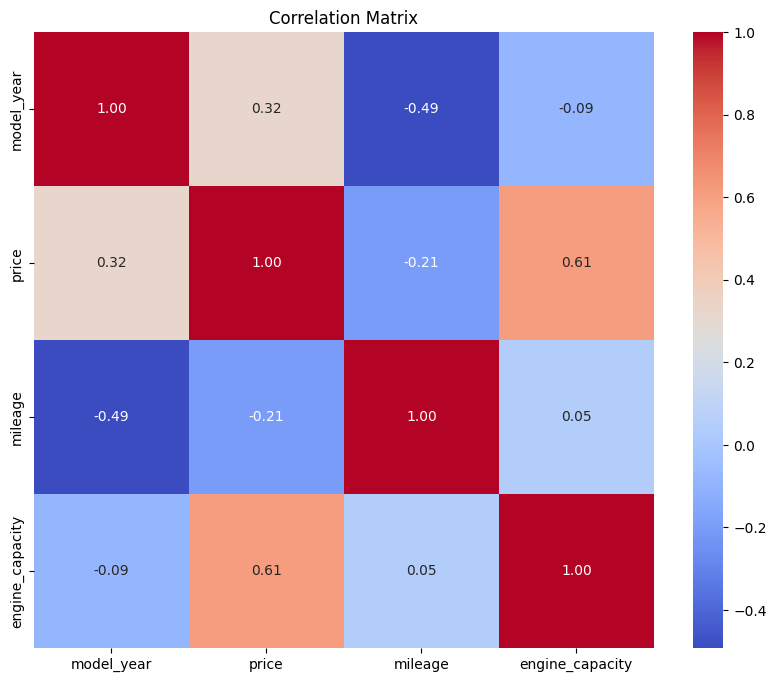

In [17]:

correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [18]:
print(correlation_matrix)

                 model_year     price   mileage  engine_capacity
model_year         1.000000  0.321152 -0.492564        -0.085457
price              0.321152  1.000000 -0.206314         0.610223
mileage           -0.492564 -0.206314  1.000000         0.049608
engine_capacity   -0.085457  0.610223  0.049608         1.000000


In [19]:
data.nunique()

,0
ad_url,73441
title,1471
location,2344
model_year,33
price,2084
mileage,8014
engine_type,3
transmission,2
registered_in,121
color,23


In [20]:
data.to_csv('pakwheels_cleaned.csv')

In [21]:
model_data = data.drop(columns=['ad_url','location','color','ad_last_updated','description','car_features','assembly','name','brand'])
model_data = model_data.dropna()
model_data = model_data.drop_duplicates()


In [22]:
encoders = {} # Initialize dictionary to store all encoders

cat_cols = model_data.select_dtypes(include=['object']).columns
for col in cat_cols:
    le_col = LabelEncoder() # Create a new encoder for each column
    model_data[col] = le_col.fit_transform(model_data[col]) # Fit and transform the model_data column
    encoders[col] = le_col # Store the fitted encoder

In [23]:
X = model_data.drop(columns=['price'])
y = model_data['price']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,         # Reduced from 6 to prevent memorization
    subsample=0.8,       # Only use 80% of data per tree
    colsample_bytree=0.8, # Only use 80% of features per tree
    reg_lambda=10,       # Added L2 regularization
    objective='reg:squarederror'
)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
model.save_model('xgb_model.pkl')

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1116: UserWarning: [17:42:19] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


In [27]:
# Predictions for both sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Calculate R2 Scores
r2_train = r2_score(y_train, train_preds)
r2_test = r2_score(y_test, test_preds)

# Calculate Errors
mae_train = mean_absolute_error(y_train, train_preds)
mae_test = mean_absolute_error(y_test, test_preds)

mse_train = mean_squared_error(y_train, train_preds)
mse_test = mean_squared_error(y_test, test_preds)

print(f"Training R2: {r2_train:.4f} | Test R2: {r2_test:.4f}")
print(f"Training MAE: {mae_train:,.4f} | Test MAE: {mae_test:,.4f}")
print(f"Training MSE: {mse_train:,.4f} | Test MSE: {mse_test:,.4f}")


Training R2: 0.9637 | Test R2: 0.9339
Training MAE: 283,395.4500 | Test MAE: 306,731.1946
Training MSE: 538,186,040,434.9125 | Test MSE: 883,199,365,134.8386


In [28]:
# Check which feature the model is using to 'cheat'
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))


engine_capacity    0.316005
transmission       0.273720
model_year         0.166932
registered_in      0.064759
title              0.057749
body_type          0.054447
mileage            0.037334
engine_type        0.029055
dtype: float32


In [29]:
def predict_car_price(year, mileage, engine_type, transmission, registered_in, capacity, body_type, title):
    # Translate words to numbers using our saved encoders
    input_data = {
        'title': [encoders['title'].transform([title])[0]],
        'model_year': [year],
        'mileage': [mileage],
        'engine_type': [encoders['engine_type'].transform([engine_type])[0]],
        'transmission': [encoders['transmission'].transform([transmission])[0]],
        'registered_in': [encoders['registered_in'].transform([registered_in])[0]],
        'engine_capacity': [capacity],
        'body_type': [encoders['body_type'].transform([body_type])[0]],

    }

    # Create DataFrame and Predict
    sample_df = pd.DataFrame(input_data)
    price = model.predict(sample_df)[0]

    print(f"--- Market Estimate ---")
    print(f"The estimated price for a {year} {title} {body_type} is: {price:,.0f} PKR")


In [30]:
predict_car_price(
    title='Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC',
    year=2018,
    mileage=60000,
    engine_type='Petrol',
    transmission='Automatic',
    registered_in='Lahore',
    capacity=1300,
    body_type='Sedan',

)


--- Market Estimate ---
The estimated price for a 2018 Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC Sedan is: 3,097,526 PKR
